In [1]:
import sys

print(sys.executable)

c:\TwinSepsis\.venv\Scripts\python.exe


In [2]:
import pandas
import numpy
import matplotlib
import sklearn
import xgboost
import shap

print("All packages imported successfully!")

All packages imported successfully!


In [3]:
from dotenv import load_dotenv
import os

load_dotenv()

data_root = os.getenv("PHYSIONET_ROOT")

print(data_root)

C:/TwinSepsis/dataset/physionet.org/files/challenge-2019/1.0.0/training


In [4]:
import sys
from pathlib import Path

# Add project root to Python path
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.config import TRAIN_A, TRAIN_B

print("Training Set A:", TRAIN_A)
print("Training Set B:", TRAIN_B)

Training Set A: C:\TwinSepsis\dataset\physionet.org\files\challenge-2019\1.0.0\training\training_setA
Training Set B: C:\TwinSepsis\dataset\physionet.org\files\challenge-2019\1.0.0\training\training_setB


In [5]:
import pandas as pd

patient_file = TRAIN_A / "p000001.psv"

patient_df = pd.read_csv(
    patient_file,
    sep="|"
)

print("Shape:", patient_df.shape)

Shape: (54, 41)


In [6]:
display(patient_df.head())

,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,1,0
1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,2,0
2,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,3,0
3,90.0,95.0,NaN,NaN,NaN,NaN,30.0,NaN,24.0,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,4,0
4,103.0,88.5,NaN,122.0,91.33,NaN,24.5,NaN,NaN,NaN,...,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,5,0


In [7]:
print("Number of rows:", len(patient_df))
print("Number of columns:", len(patient_df.columns))

Number of rows: 54
Number of columns: 41


In [8]:
print(patient_df.columns.tolist())

['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel']


In [9]:
patient_df.dtypes

HR                  float64
O2Sat               float64
Temp                float64
SBP                 float64
MAP                 float64
DBP                 float64
Resp                float64
EtCO2               float64
BaseExcess          float64
HCO3                float64
FiO2                float64
pH                  float64
PaCO2               float64
SaO2                float64
AST                 float64
BUN                 float64
Alkalinephos        float64
Calcium             float64
Chloride            float64
Creatinine          float64
Bilirubin_direct    float64
Glucose             float64
Lactate             float64
Magnesium           float64
Phosphate           float64
Potassium           float64
Bilirubin_total     float64
TroponinI           float64
Hct                 float64
Hgb                 float64
PTT                 float64
WBC                 float64
Fibrinogen          float64
Platelets           float64
Age                 float64
Gender              

In [10]:
patient_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 41 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   HR                49 non-null     float64
 1   O2Sat             44 non-null     float64
 2   Temp              10 non-null     float64
 3   SBP               42 non-null     float64
 4   MAP               42 non-null     float64
 5   DBP               0 non-null      float64
 6   Resp              50 non-null     float64
 7   EtCO2             0 non-null      float64
 8   BaseExcess        7 non-null      float64
 9   HCO3              2 non-null      float64
 10  FiO2              4 non-null      float64
 11  pH                7 non-null      float64
 12  PaCO2             6 non-null      float64
 13  SaO2              4 non-null      float64
 14  AST               1 non-null      float64
 15  BUN               2 non-null      float64
 16  Alkalinephos      1 non-null      float64
 17  Calcium   

In [11]:
missing = patient_df.isna().sum()

display(missing[missing > 0].sort_values(ascending=False))

Fibrinogen          54
Unit1               54
EtCO2               54
DBP                 54
Unit2               54
TroponinI           54
Lactate             54
Bilirubin_direct    54
PTT                 54
Bilirubin_total     53
Alkalinephos        53
AST                 53
Phosphate           52
Potassium           52
Glucose             52
Magnesium           52
BUN                 52
Calcium             52
HCO3                52
Chloride            52
Platelets           52
Hgb                 52
Hct                 52
Creatinine          52
WBC                 52
FiO2                50
SaO2                50
PaCO2               48
BaseExcess          47
pH                  47
Temp                44
SBP                 12
MAP                 12
O2Sat               10
HR                   5
Resp                 4
dtype: int64

In [12]:
print(patient_df["SepsisLabel"].value_counts())

SepsisLabel
0    54
Name: count, dtype: int64


In [13]:
print(patient_df["SepsisLabel"].value_counts(normalize=True) * 100)

SepsisLabel
0    100.0
Name: proportion, dtype: float64


In [14]:
sepsis_hours = patient_df[
    patient_df["SepsisLabel"] == 1
]

print(sepsis_hours[["ICULOS", "SepsisLabel"]])

Empty DataFrame
Columns: [ICULOS, SepsisLabel]
Index: []


In [15]:
import glob

septic_patient = None

for file in glob.glob(str(TRAIN_A / "*.psv")):
    temp = pd.read_csv(file, sep="|", usecols=["SepsisLabel"])
    
    if temp["SepsisLabel"].max() == 1:
        septic_patient = Path(file)
        break

print("First septic patient found:", septic_patient)

First septic patient found: C:\TwinSepsis\dataset\physionet.org\files\challenge-2019\1.0.0\training\training_setA\p000009.psv


In [16]:
septic_df = pd.read_csv(
    septic_patient,
    sep="|"
)

print("Patient:", septic_patient.stem)
print("Number of ICU hours:", len(septic_df))

Patient: p000009
Number of ICU hours: 258


In [17]:
septic_df[
    septic_df["SepsisLabel"] == 1
][["ICULOS", "SepsisLabel"]].head(20)

,ICULOS,SepsisLabel
248,249,1
249,250,1
250,251,1
251,252,1
252,253,1
253,254,1
254,255,1
255,256,1
256,257,1
257,258,1


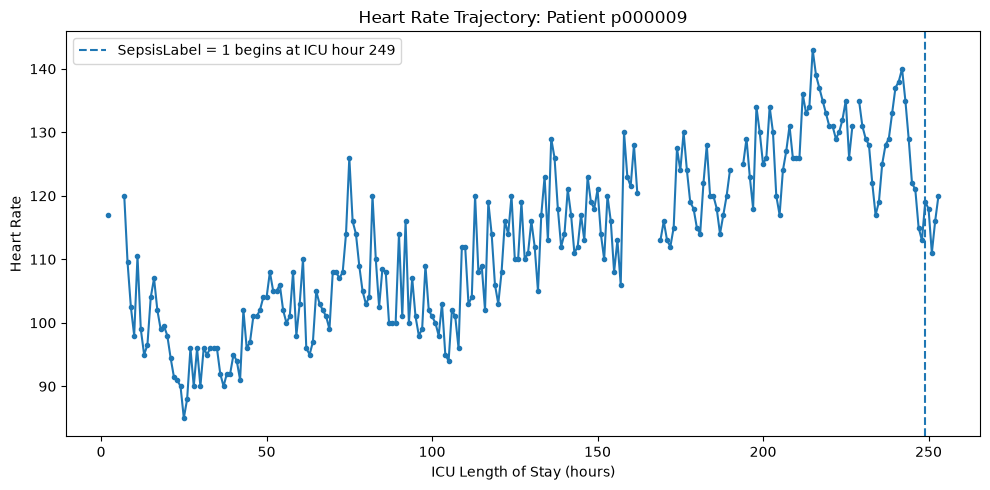

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    septic_df["ICULOS"],
    septic_df["HR"],
    marker="o",
    markersize=3
)

sepsis_start = septic_df.loc[
    septic_df["SepsisLabel"] == 1,
    "ICULOS"
].min()

plt.axvline(
    sepsis_start,
    linestyle="--",
    label=f"SepsisLabel = 1 begins at ICU hour {sepsis_start}"
)

plt.xlabel("ICU Length of Stay (hours)")
plt.ylabel("Heart Rate")
plt.title(f"Heart Rate Trajectory: Patient {septic_patient.stem}")
plt.legend()
plt.tight_layout()
plt.show()

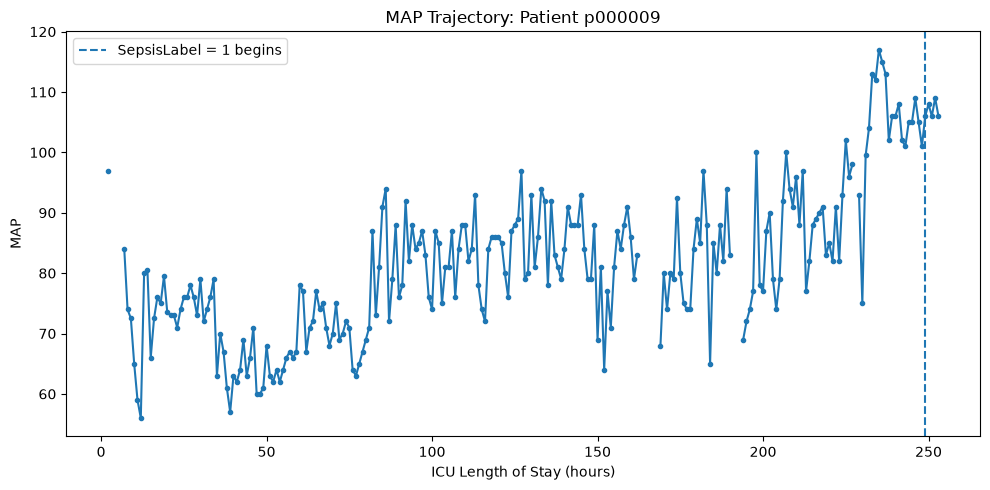

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(
    septic_df["ICULOS"],
    septic_df["MAP"],
    marker="o",
    markersize=3
)

plt.axvline(
    sepsis_start,
    linestyle="--",
    label="SepsisLabel = 1 begins"
)

plt.xlabel("ICU Length of Stay (hours)")
plt.ylabel("MAP")
plt.title(f"MAP Trajectory: Patient {septic_patient.stem}")
plt.legend()
plt.tight_layout()
plt.show()